# ORDER AND PAYMENT ANALYSIS

## BUSINESS CASE

1. Payment type mana (credit card, boleto, voucher, debit card) yang paling banyak digunakan?
2. Bagaimana distribusi jumlah cicilan (installments) pada pembayaran credit card?
3. Apakah jumlah cicilan berkorelasi dengan nilai order yang lebih tinggi?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order_payment = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_payments_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order_payment.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**GRAIN** 
1. 1 baris = 1 record pembayaran untuk sebuah order.

**KEY COLUMN**
- `order_id` → identifier untuk setiap order
- `payment_sequential` → urutan pembayaran tiap order
- `payment_type` → tipe pembayaran
- `payment_installments` → jumlah cicilan
- `payment_value` → nilai pembayaran

## DATA QUALITY

### ASESSING DATA

In [4]:
order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [5]:
order_payment.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [6]:
print('Checking null value')
order_payment.isna().sum()

Checking null value


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [7]:
print('Checking duplicated value')
order_payment.duplicated().sum()

Checking duplicated value


0

In [8]:
#CHECKING MULTIPLE PAYMENT TYPE PER ORDER
multiple_payment_type = (
    order_payment.groupby('order_id')['payment_type']
    .nunique()
    .reset_index(name='total_payment_type')
)

multiple_payment_type[multiple_payment_type['total_payment_type'] > 1]

,order_id,total_payment_type
36,0016dfedd97fc2950e388d2971d718c7,2
215,009ac365164f8e06f59d18a08045f6c4,2
258,00b4a910f64f24dbcac04fe54088a443,2
274,00bd50cdd31bd22e9081e6e2d5b3577b,2
282,00c405bd71187154a7846862f585a9d4,2
...,...,...
99123,ff1f8f328e5a59ac754240b6dd31bcb4,2
99125,ff20ee702706d9e407a34de9fe2ff768,2
99241,ff7400d904161b62b6e830b3988f5cbd,2
99304,ffa1dd97810de91a03abd7bd76d2fed1,2


In [9]:
print('jumlah order yang mempunyai payment_type lebih dari satu')
(multiple_payment_type['total_payment_type'] > 1).sum()

jumlah order yang mempunyai payment_type lebih dari satu


2246

**DATA QUALITY NOTE**
1. Satu order_id dapat memiliki lebih dari satu payment_type, perhitungan jumlah order berdasarkan payment_type menggunakan unique order_id pada masing-masing payment type, sehingga total order antar payment type tidak dapat dijumlahkan secara langsung.

### CLEANING DATA

## DATA PREPARATION

## EXPLORATORY DATA ANALYSIS

### 1. Payment type mana (credit card, boleto, voucher, debit card) yang paling banyak digunakan?

In [10]:
type_payment = order_payment.groupby('payment_type').agg({
    'order_id' : 'nunique',
    'payment_value' : 'sum'
}).sort_values(by='order_id', ascending=False).reset_index()
type_payment

,payment_type,order_id,payment_value
0,credit_card,76505,12542084.19
1,boleto,19784,2869361.27
2,voucher,3866,379436.87
3,debit_card,1528,217989.79
4,not_defined,3,0.00


In [11]:
grand_total_type_payment =  type_payment['order_id'].sum()

In [12]:
type_payment['pct'] = (type_payment['order_id'] / grand_total_type_payment * 100).round(4)
type_payment

,payment_type,order_id,payment_value,pct
0,credit_card,76505,12542084.19,75.2365
1,boleto,19784,2869361.27,19.4560
2,voucher,3866,379436.87,3.8019
3,debit_card,1528,217989.79,1.5027
4,not_defined,3,0.00,0.0030


In [13]:
type_payment = type_payment.rename(columns={
    'order_id': 'Total order',
    'payment_value': 'Total Revenue',
    }
)

C:\Users\adien\AppData\Local\Temp\ipykernel_728\674044564.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


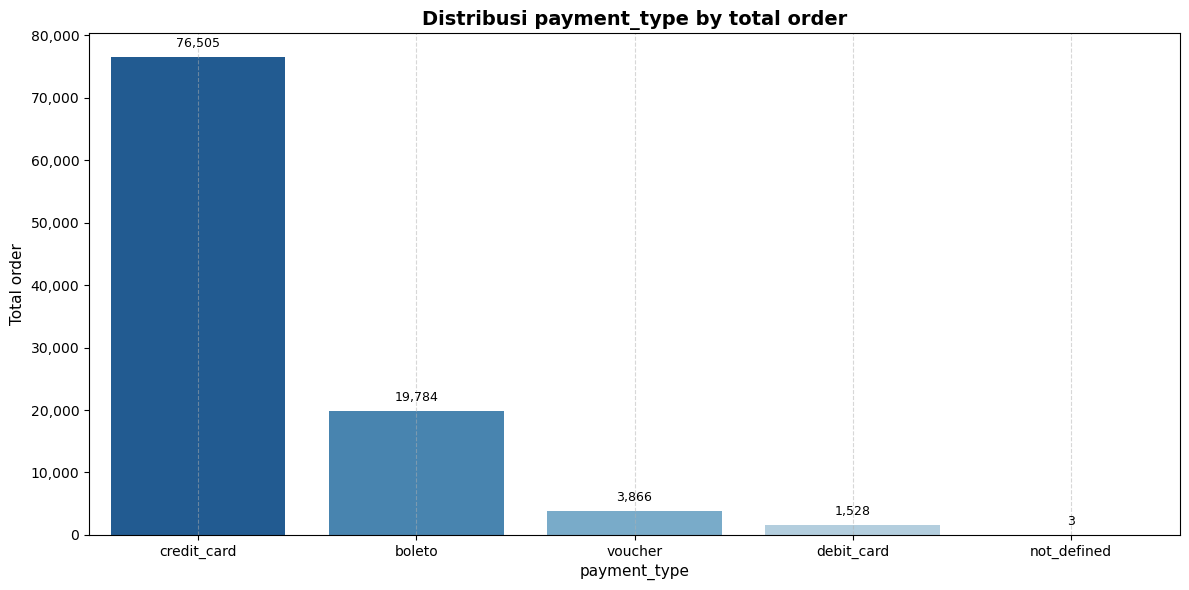

In [14]:
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=type_payment,
    x='payment_type',            # Sumbu X (Angka)
    y='Total order',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Distribusi payment_type by total order', fontsize=14, fontweight='bold')
plt.xlabel('payment_type', fontsize=11)
plt.ylabel('Total order', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

C:\Users\adien\AppData\Local\Temp\ipykernel_728\121932436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


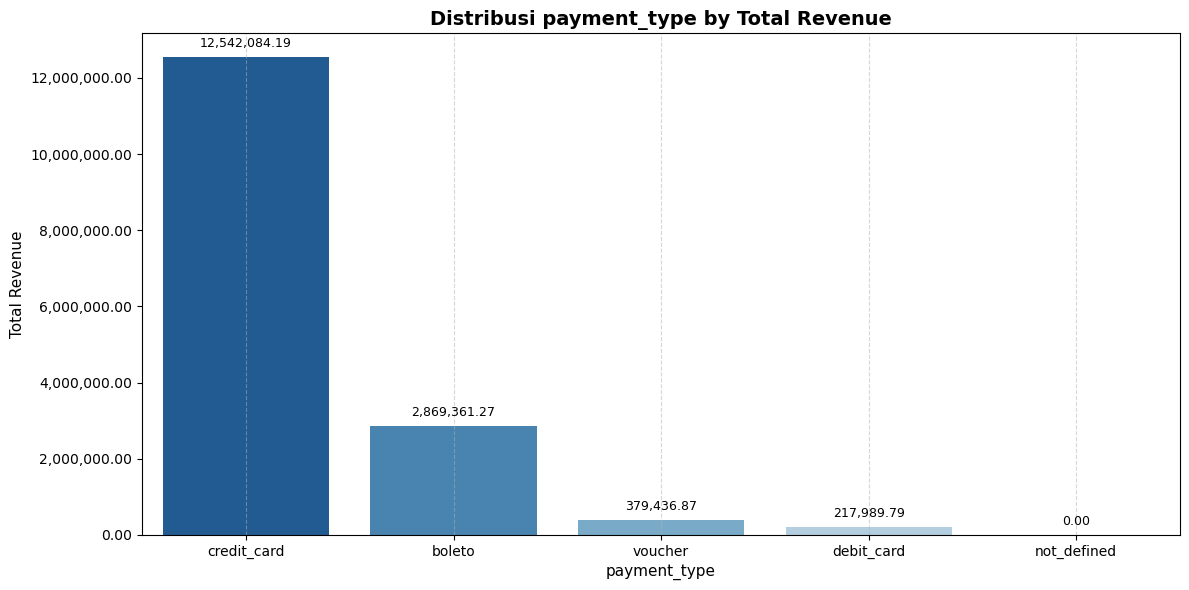

In [15]:
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=type_payment,
    x='payment_type',            # Sumbu X (Angka)
    y='Total Revenue',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

# 6. Judul dan Label Sumbu
plt.title('Distribusi payment_type by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('payment_type', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. Total order dengan tipe payment tertinggi yaitu credit card dengan total 76.505 order dan total nilai pembayaran sebesar 12.542.084,19
2. Total order dengan tipe payment tertinggi kedua yaitu boleto dengan total 19,784 order dan total nilai pembayaran sebesar 2.869.361,27

### 2. Bagaimana distribusi jumlah cicilan (installments) pada pembayaran credit card?

In [16]:
distribution_installments = order_payment[['order_id','payment_installments','payment_type']]
distribution_installments = order_payment[order_payment['payment_type'] == 'credit_card']

In [17]:
distribution_installments = distribution_installments.groupby('payment_installments').agg({
    'order_id' : 'nunique'
}).sort_values(by='payment_installments', ascending=True).reset_index()
distribution_installments

,payment_installments,order_id
0,0,2
1,1,25407
2,2,12389
3,3,10443
4,4,7088
5,5,5234
6,6,3916
7,7,1623
8,8,4253
9,9,644


In [18]:
grand_total_payment_installments = distribution_installments['order_id'].sum()
distribution_installments['pct'] = ((distribution_installments['order_id'] / grand_total_payment_installments) * 100).round(4)
distribution_installments

,payment_installments,order_id,pct
0,0,2,0.0026
1,1,25407,33.1446
2,2,12389,16.1620
3,3,10443,13.6234
4,4,7088,9.2466
5,5,5234,6.8280
6,6,3916,5.1086
7,7,1623,2.1173
8,8,4253,5.5482
9,9,644,0.8401


In [19]:
distribution_installments = distribution_installments.rename(columns={
    'order_id': 'Total order',
    }
)
distribution_installments

,payment_installments,Total order,pct
0,0,2,0.0026
1,1,25407,33.1446
2,2,12389,16.1620
3,3,10443,13.6234
4,4,7088,9.2466
5,5,5234,6.8280
6,6,3916,5.1086
7,7,1623,2.1173
8,8,4253,5.5482
9,9,644,0.8401


C:\Users\adien\AppData\Local\Temp\ipykernel_728\1619263370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


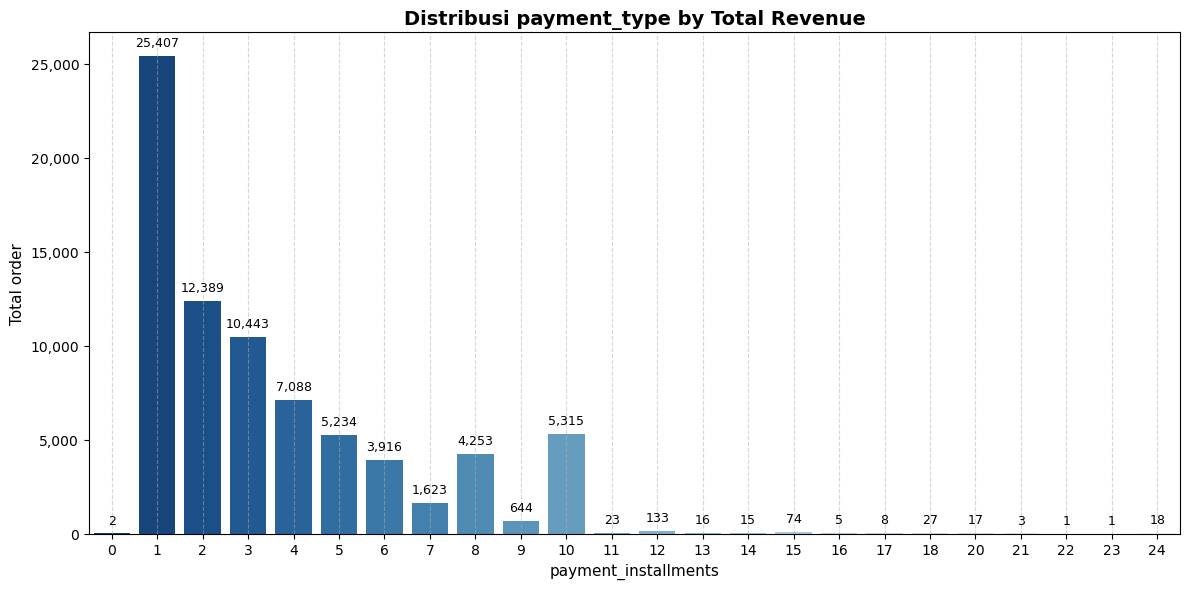

In [20]:
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=distribution_installments,
    x='payment_installments',            # Sumbu X (Angka)
    y='Total order',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Distribusi payment_type by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('payment_installments', fontsize=11)
plt.ylabel('Total order', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

Pembayaran credit card didominasi oleh 1 kali cicilan dengan 25.407 order. Setelah itu, penggunaan cicilan cenderung menurun seiring bertambahnya jumlah cicilan, meskipun cicilan 2–10 kali masih memiliki volume penggunaan yang cukup tinggi.

### 3. Apakah jumlah cicilan berkorelasi dengan nilai order yang lebih tinggi?

In [21]:
correlation = order_payment[['order_id','payment_installments','payment_value']]

In [22]:
correlation = correlation.groupby('payment_installments').agg({
    'order_id' : 'nunique',
    'payment_value' : 'sum'
}).sort_values(by='payment_installments', ascending=True).reset_index()
correlation

,payment_installments,order_id,payment_value
0,0,2,188.63
1,1,49060,5907233.36
2,2,12389,1579283.03
3,3,10443,1491103.80
4,4,7088,1163907.61
5,5,5234,961174.30
6,6,3916,822611.81
7,7,1623,305157.39
8,8,4253,1313423.34
9,9,644,131015.92


In [23]:
correlation['avg_payment_value'] = (
    correlation['payment_value'] / correlation['order_id']
).round(2)
correlation

,payment_installments,order_id,payment_value,avg_payment_value
0,0,2,188.63,94.32
1,1,49060,5907233.36,120.41
2,2,12389,1579283.03,127.47
3,3,10443,1491103.80,142.79
4,4,7088,1163907.61,164.21
5,5,5234,961174.30,183.64
6,6,3916,822611.81,210.06
7,7,1623,305157.39,188.02
8,8,4253,1313423.34,308.82
9,9,644,131015.92,203.44


In [24]:
cor = correlation[['payment_installments', 'avg_payment_value']]
cor.corr()

,payment_installments,avg_payment_value
payment_installments,1.000000,0.602134
avg_payment_value,0.602134,1.000000


#### KEY INSIGHT

Terdapat korelasi positif sedang (0,60) antara jumlah cicilan dan rata-rata nilai pembayaran. Semakin tinggi jumlah cicilan, rata-rata nilai pembayaran cenderung semakin tinggi.

## KEY FINDINGS

1. Total order dengan tipe payment tertinggi yaitu credit card dengan total 76.505 order dan total nilai pembayaran 12.542.084,19
2. Total order dengan tipe payment tertinggi kedua yaitu boleto dengan total 19,784 order dan total nilai pembayaran sebesar 2.869.361,27
3. Pembayaran credit card didominasi oleh 1 kali cicilan dengan 25.407 order. Setelah itu, penggunaan cicilan cenderung menurun seiring bertambahnya jumlah cicilan, meskipun cicilan 2–10 kali masih memiliki volume penggunaan yang cukup tinggi.
4. Terdapat korelasi positif sedang (0,60) antara jumlah cicilan dan rata-rata nilai pembayaran. Semakin tinggi jumlah cicilan, rata-rata nilai pembayaran cenderung semakin tinggi.

## BUSINESS IMPLICATIONS

1. Credit card menjadi metode pembayaran yang paling banyak digunakan, sehingga pengalaman pembayaran melalui credit card perlu dipastikan tetap mudah, cepat, dan tersedia dengan baik.
2. Tingginya penggunaan pembayaran 1 kali cicilan menunjukkan adanya preferensi terhadap pembayaran tanpa tenor panjang. Bisnis dapat mempertimbangkan struktur opsi cicilan yang sesuai dengan pola penggunaan pelanggan.
3. Korelasi positif sedang antara jumlah cicilan dan rata-rata nilai pembayaran menunjukkan bahwa transaksi dengan jumlah cicilan lebih tinggi cenderung memiliki nilai pembayaran yang lebih tinggi. Bisnis dapat mengevaluasi penggunaan opsi cicilan pada transaksi bernilai tinggi, namun diperlukan analisis lanjutan untuk memastikan hubungan tersebut tidak dipengaruhi faktor lain.